In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

PATH = "Crashes.csv"
df = pd.read_csv(PATH)

print("========== BASIC DATASET INFO ==========")
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

print("\nData Types:\n")
print(df.dtypes)

print("\nMissing Values:\n")
print(df.isnull().sum().sort_values(ascending=False).head(15))

print("\nBasic Statistics (numeric):\n")
print(df.describe())

# Raw injury info distribution (before severity creation)
if "NUMBER_INJURED" in df.columns:
    print("\nInjury Count Distribution:")
    print(df["NUMBER_INJURED"].value_counts().head())

if "NUMBER_KILLED" in df.columns:
    print("\nFatality Count Distribution:")
    print(df["NUMBER_KILLED"].value_counts().head())

df.columns = [c.strip().upper() for c in df.columns]


if "COLLISION_DATE" in df.columns:
    df["COLLISION_DATE"] = pd.to_datetime(df["COLLISION_DATE"], errors="coerce")
    df["CRASH_MONTH"] = df["COLLISION_DATE"].dt.month
    df["CRASH_DAY"] = df["COLLISION_DATE"].dt.day
    df["CRASH_YEAR_FROM_DATE"] = df["COLLISION_DATE"].dt.year

if "COLLISION_TIME" in df.columns:
    
    t = df["COLLISION_TIME"].astype(str).str.replace(r"\D", "", regex=True)
    t = t.str.zfill(4)

    df["CRASH_HOUR"] = pd.to_numeric(t.str[:2], errors="coerce")

    df["CRASH_HOUR"] = df["CRASH_HOUR"].where(df["CRASH_HOUR"].between(0, 23), np.nan)

for col in ["NUMBER_KILLED", "NUMBER_INJURED"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)


df["SEVERITY_3CLASS"] = np.select(
    [
        df["NUMBER_KILLED"] > 0,
        df["NUMBER_INJURED"] >= 3,
        df["NUMBER_INJURED"].between(1, 2, inclusive="both"),
    ],
    [2, 2, 1],
    default=0,
).astype(int)

print("========== AFTER FEATURE ENGINEERING ==========")

print("Severity Class Distribution (0=Low,1=Moderate,2=High):")
severity_counts = df["SEVERITY_3CLASS"].value_counts().sort_index()
print(severity_counts)

print("Severity Percentage Distribution:")
print((severity_counts / len(df) * 100).round(2))

# Check class imbalance warning
if severity_counts.min() / severity_counts.max() < 0.2:
    print(" Class imbalance detected — model may need balancing.")
else:
    print(" Class distribution looks reasonable.")

drop_cols = {
    "SEVERITY_3CLASS",
    "NUMBER_KILLED",
    "NUMBER_INJURED",
    "COLLISION_SEVERITY",  
    "COLLISION_DATE",      
    "PROC_DATE",           
}
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].copy()
y = df["SEVERITY_3CLASS"].copy()

high_id_like = [c for c in X.columns if c.endswith("_ID") or c in ["CASE_ID", "OFFICER_ID"]]
X = X.drop(columns=[c for c in high_id_like if c in X.columns], errors="ignore")


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

numeric_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_cols),
        ("cat", categorical_pipe, categorical_cols),
    ],
    remainder="drop"
)

print("\n========== POST-CLEANING FEATURE INFO ==========")
print("Total Features Used:", len(feature_cols))
print("Feature List:\n", feature_cols)


========== BASIC DATASET INFO ==========
Shape: (193500, 80)

Columns:
 ['CASE_ID', 'ACCIDENT_YEAR', 'PROC_DATE', 'JURIS', 'COLLISION_DATE', 'COLLISION_TIME', 'OFFICER_ID', 'REPORTING_DISTRICT', 'DAY_OF_WEEK', 'CHP_SHIFT', 'POPULATION', 'CNTY_CITY_LOC', 'SPECIAL_COND', 'BEAT_TYPE', 'CHP_BEAT_TYPE', 'CITY_DIVISION_LAPD', 'CHP_BEAT_CLASS', 'BEAT_NUMBER', 'PRIMARY_RD', 'SECONDARY_RD', 'DISTANCE', 'DIRECTION', 'INTERSECTION', 'WEATHER_1', 'WEATHER_2', 'STATE_HWY_IND', 'CALTRANS_COUNTY', 'CALTRANS_DISTRICT', 'STATE_ROUTE', 'ROUTE_SUFFIX', 'POSTMILE_PREFIX', 'POSTMILE', 'LOCATION_TYPE', 'RAMP_INTERSECTION', 'SIDE_OF_HWY', 'TOW_AWAY', 'COLLISION_SEVERITY', 'NUMBER_KILLED', 'NUMBER_INJURED', 'PARTY_COUNT', 'PRIMARY_COLL_FACTOR', 'PCF_CODE_OF_VIOL', 'PCF_VIOL_CATEGORY', 'PCF_VIOLATION', 'PCF_VIOL_SUBSECTION', 'HIT_AND_RUN', 'TYPE_OF_COLLISION', 'MVIW', 'PED_ACTION', 'ROAD_SURFACE', 'ROAD_COND_1', 'ROAD_COND_2', 'LIGHTING', 'CONTROL_DEVICE', 'CHP_ROAD_TYPE', 'PEDESTRIAN_ACCIDENT', 'BICYCLE_ACCID

# Model Building and Evaluation

## Logistic Regression Baseline

In [2]:
model = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=1000,
    class_weight="balanced"  
)

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
])

# Train
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

print("Confusion Matrix (rows=true, cols=pred):")
print(confusion_matrix(y_test, y_pred))
print()

print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))


c:\Users\abhin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\abhin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Confusion Matrix (rows=true, cols=pred):
[[30034  4532]
 [  771  3363]]

Classification Report:
              precision    recall  f1-score   support

           1     0.9750    0.8689    0.9189     34566
           2     0.4260    0.8135    0.5591      4134

    accuracy                         0.8630     38700
   macro avg     0.7005    0.8412    0.7390     38700
weighted avg     0.9163    0.8630    0.8805     38700



## ANN Model 1: Baseline ANN (Before Tuning)

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

X_train_processed = preprocess.fit_transform(X_train)
X_test_processed = preprocess.transform(X_test)

model1 = Sequential()
model1.add(Dense(64, activation='relu', input_shape=(X_train_processed.shape[1],)))
model1.add(Dense(32, activation='relu'))
model1.add(Dense(3, activation='softmax'))

model1.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history1 = model1.fit(
    X_train_processed,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

y_pred_probs_1 = model1.predict(X_test_processed)
y_pred_1 = np.argmax(y_pred_probs_1, axis=1)

print("Model 1 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_1))
print()

print("Model 1 Classification Report:")
print(classification_report(y_test, y_pred_1, digits=4))

loss1, acc1 = model1.evaluate(X_test_processed, y_test, verbose=0)
print(f"\nModel 1 Test Accuracy: {acc1 * 100:.2f}%")

c:\Users\abhin\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\abhin\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\abhin\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorflow/core/framewo

Epoch 1/20
3870/3870 ━━━━━━━━━━━━━━━━━━━━ 95s 24ms/step - accuracy: 0.8688 - loss: 0.8073 - val_accuracy: 0.8929 - val_loss: 0.3314
Epoch 2/20
3870/3870 ━━━━━━━━━━━━━━━━━━━━ 96s 25ms/step - accuracy: 0.8929 - loss: 0.3397 - val_accuracy: 0.8926 - val_loss: 0.3536
Epoch 3/20
3870/3870 ━━━━━━━━━━━━━━━━━━━━ 98s 25ms/step - accuracy: 0.8929 - loss: 0.3107 - val_accuracy: 0.8926 - val_loss: 0.3014
Epoch 4/20
3870/3870 ━━━━━━━━━━━━━━━━━━━━ 97s 25ms/step - accuracy: 0.9129 - loss: 0.2508 - val_accuracy: 0.9455 - val_loss: 0.1784
Epoch 5/20
3870/3870 ━━━━━━━━━━━━━━━━━━━━ 97s 25ms/step - accuracy: 0.9279 - loss: 0.2198 - val_accuracy: 0.8960 - val_loss: 0.3125
Epoch 6/20
3870/3870 ━━━━━━━━━━━━━━━━━━━━ 97s 25ms/step - accuracy: 0.9349 - loss: 0.2013 - val_accuracy: 0.9042 - val_loss: 0.2469
Epoch 7/20
3870/3870 ━━━━━━━━━━━━━━━━━━━━ 97s 25ms/step - accuracy: 0.9390 - loss: 0.1941 - val_accuracy: 0.9558 - val_loss: 0.1423
Epoch 8/20
3870/3870 ━━━━━━━━━━━━━━━━━━━━ 99s 26ms/step - accuracy: 0.9444 -

## Model 1 Accuracy Graph

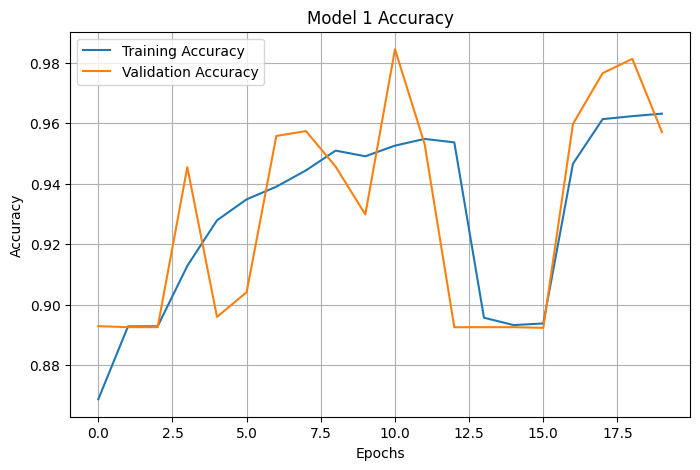

In [4]:
plt.figure(figsize=(8, 5))
plt.plot(history1.history['accuracy'], label='Training Accuracy')
plt.plot(history1.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model 1 Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()